# Imports

In [25]:
%load_ext autoreload
%autoreload 2
import os
import os.path
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
base_path = os.getcwd()
parent_path = os.path.dirname(base_path)
input_path = os.path.join(parent_path, "test_data", "Fe3O4Nanoparticles_VSANS26903", "raw_data")
save_path = os.path.join(parent_path, "test_data", "Fe3O4Nanoparticles_VSANS26903", "processed_data")
print(input_path)
print(save_path)

c:\Users\klkry\Workspace\Git\sans_polarization_reduction\test_data\Fe3O4Nanoparticles_VSANS26903\raw_data
c:\Users\klkry\Workspace\Git\sans_polarization_reduction\test_data\Fe3O4Nanoparticles_VSANS26903\processed_data


In [27]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
print(sys.path)

# Now import your functions
from sans_reduction_utilites.reduction_functions import *
from sans_reduction_utilites.polarization_correction_functions import *

['c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\Workspace\\Git\\sans_polarization_reduction\\src', 'c:\\Users\\klkry\\miniforge3\\envs\\image-processing\\python314.zip', 'c:\\Users\\klkry\\miniforge3\\envs\\image-processing\\DLLs', 'c:\\Users\\klkry\\miniforge3\\envs\\image-processing\\Lib', 'c:\\Users\\klkry\\miniforge3\\envs\\image-processing', '', 'c:\\Users\\klkry\\miniforge3\\envs\\image-processing\\Lib\\site-packages']


In [28]:
Instrument = 'VSANS' #Choices are 'VASNS', 'NG7SANS'
SectorCutAngles = 15.0 #Default is typically 10.0 to 20.0 (degrees)
StrucutrallyIsotropic = 0 #0 is the safe bet if you don't know if your sample is strucutrally isotropic

#********************************************************************
#**** Run with defaults, unless have reason to do otherwise *********
#********************************************************************

TempDiffAllowedForSharingTrans = 20.0 #Max temperature difference in K to fill in for missing transmission files
AutoSubtractEmpty = 1 #Default is 1 for yes; 0 for no. Selecting 1 doesn't cause any issues even if no empties are available.
YesNoRenameEmpties = 1 #0 = No; 1 = Yes and will simply rename to Empty
UseMTCirc = 1 #Default is 1 for yes, 0 for no (which instead subtracts sector-by-sector MT from data)
He3Only_Check = 0 #Default 0 = No (runs full reduction), 1 = Yes (for helium team's use)
Absolute_Q_min = 0.005 #Default 0; Will take the maximum of Q_min_Calc from all detectors and this value
Absolute_Q_max = 0.12 #Default 0.6; Will take the minimum of Q_max_Calc from all detectors and this value

Excluded_Filenumbers = [] #[Use filenumers separated by commas as needed]
ReAssignBlockBeam = []
ReAssignEmpty = []
ReAssignOpen = []
ReAssignSample = []
Min_Filenumber = 0 #Default 0
Max_Filenumber = 1000000 #Default 1000000
Min_Scatt_Filenumber = Min_Filenumber
Max_Scatt_Filenumber = Max_Filenumber
Min_Trans_Filenumber = Min_Filenumber
Max_Trans_Filenumber = Max_Filenumber
SampleDescriptionKeywordsToExclude = []

YesNoSetPlotXRange = 0 #Default is 0 (no), 1 = yes
YesNoSetPlotYRange = 0 #Default is 0 (no), 1 = yes
PlotXmin = 0.015 #Only used if YesNoSetPlotXRange = 1
PlotXmax = 0.115 #Only used if YesNoSetPlotXRange = 1
PlotYmin = 1E-4 #Only used if YesNoSetPlotYRange = 1
PlotYmax = 1 #Only used if YesNoSetPlotYRange = 1

In [29]:
#The following paramters should rarely be touched (just initialize this cell)
SampleApertureInMM = True #Override in case sample aperture entered in cm rather than mm
PreSebtractOpen = 0 #Default is 0 for no; 1 for yes. Subtracts trans-scaled open (if available) from pol-full in attempt to remove main beam spillover.
Calc_Q_From_Trans = 1 #Default is 1 for yes; 0 for no
AverageQRanges = 0 #0 for no; 1 for yes
YesNoShowPlots = 0 #0 = No and simply saves plots; 1 = yes and displays plots when code is run
CompareUnpolCirc = 1
CompareHalfPolSumCirc = 1
CompareFullPolSumCirc = 1
CompareFullPolStruc = 1
CompareFullPolMagnetism = 1
YesNo_2DCombinedFiles = 0 #Default is 0 (no), 1 = yes which can be read using SasView
YesNo_2DFilesPerDetector = 0 #Default is 0 (no), 1 = yes; Note all detectors will be summed after beamline masking applied and can be read by SasView 4.2.2 (and higher?)
MidddlePixelBorderHorizontal = 4 #Default = 4
MidddlePixelBorderVertical = 4 #Default = 4
ConvertHighResToSubset = 1 #Default = 1 for yes (uses only a small subset of the million plus pixels for approximately an 18 x's savings in computing power).
HighResGain = 100.0
UsePolCorr = 1 #Default is 1 to pol-correct full-pol data, 0 means no and will only correct for 3He transmission as a function of time.
He3CorrectionType = 1 #0 for chi, 1 for chi = upsilon (only active if YesNoManualHe3Entry = 1), 2 for upsilon
YesNoBypassBestGuessPSM = 0 #Default is 1, will bypass to higher (or the highest) PSM value if one (or more) is/are measured
PSM_Guess = 0.9985 #0.9985 is good for 4 guides, 5.5 angstroms
Minimum_PSM = 0.01
YesNoManualHe3Entry = 0 #0 for no (default), 1 for yes; should not be needed for data taken after July 2019 if He3 cells are properly registered
New_HE3_Files = [77070, 77297, 77566] #Default is []; These would be the starting files for each new cell IF YesNoManualHe3Entry = 1
MuValues = [3.105, 3.374, 3.105] #Default is []; Values only used IF YesNoManualHe3Entry = 1; example [3.374, 3.105]=[Fras, Bur]; should not be needed after July 2019
TeValues = [0.86, 0.86, 0.86] #Default is []; Values only used IF YesNoManualHe3Entry = 1; example [0.86, 0.86]=[Fras, Bur]; should not be needed after July 2019
#High Res Detector is linked to then Converging Beam option (at 6.7 angstroms)
HighResMinX = 240 #Default 240
HighResMaxX = 474 #Default 474
HighResMinY = 667 #Default 667
HighResMaxY = 917 #Default 917

Plex file not found; populated with ones instead
 
He3Cell Summary for Cell Identity Frascati437252.45417194447
PolCell0:  0.9787364727777427 +/- 0.000465199739303479
AtomicPol0:  0.7268271383380185 +/- 0.001772687558288129
Gamma (hours):  333.72199018331474 +/- 31.409199633877616
     


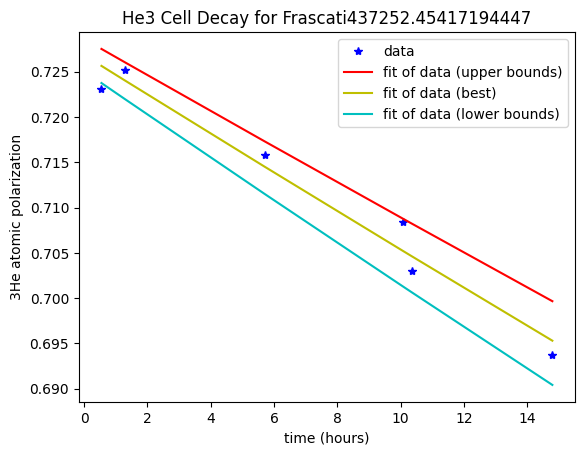

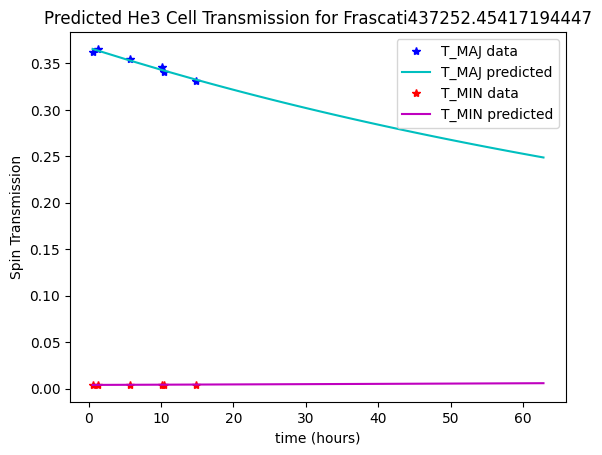

{np.float64(437252.45417194447): {'Atomic_P0': np.float64(0.7268271383380185), 'Atomic_P0_Unc': np.float64(0.001772687558288129), 'Gamma(hours)': np.float64(333.72199018331474), 'Gamma_Unc': np.float64(31.409199633877616), 'Mu': np.float32(3.1184998), 'Te': np.float32(0.86), 'Name': 'Frascati437252.45417194447', 'Neutron_P0': np.float64(0.9787364727777427), 'Neutron_P0_Unc': np.float64(0.000465199739303479)}}


In [30]:
#Run this cell to sort files and get 3He decay curves (as applicable)

Contents = "not used"
if not os.path.exists(save_path):
    os.makedirs(save_path)


Detector_Panels, TransPanel, Slices = instrument_selection()

(Sample_Names, Sample_Bases, Configs, BlockBeamCatalog, ScattCatalog, TransCatalog, Pol_TransCatalog, 
AlignDet_Trans, HE3_TransCatalog, start_number, 
filenumberlisting) = sans_sort_data_automatic(Detector_Panels, 
                                                Instrument, 
                                                UsePolCorr, 
                                                SampleDescriptionKeywordsToExclude, 
                                                TransPanel, 
                                                input_path, 
                                                YesNoManualHe3Entry, 
                                                New_HE3_Files, 
                                                MuValues, 
                                                TeValues, 
                                                Excluded_Filenumbers, 
                                                Min_Filenumber, 
                                                Max_Filenumber, 
                                                Min_Scatt_Filenumber, 
                                                Max_Scatt_Filenumber, 
                                                Min_Trans_Filenumber, 
                                                Max_Trans_Filenumber, 
                                                ReAssignBlockBeam, 
                                                ReAssignEmpty, 
                                                ReAssignOpen, 
                                                ReAssignSample, 
                                                YesNoRenameEmpties)

AlignDet_Trans = AllSANS_ShareAlignDetTransCatalog(Detector_Panels, 
                                                   Instrument, 
                                                   TempDiffAllowedForSharingTrans, 
                                                   AlignDet_Trans, 
                                                   ScattCatalog)
TransCatalog =AllSANS_ShareSampleBaseTransCatalog(Detector_Panels, 
                                                  Instrument, 
                                                  TransCatalog, 
                                                  ScattCatalog)
ScattCatalog = AllSANS_ShareEmptyPolBeamScattCatalog(ScattCatalog)
Pol_TransCatalog = VSANS_SharePolTransCatalog(Detector_Panels, 
                                              Instrument, 
                                              SampleDescriptionKeywordsToExclude, 
                                              TempDiffAllowedForSharingTrans, 
                                              Pol_TransCatalog, 
                                              ScattCatalog, 
                                              input_path)

HE3_TransCatalog = AllSANS_ProcessHe3TransCatalog(Detector_Panels, 
                                                  Instrument, 
                                                  input_path, 
                                                  HE3_TransCatalog, 
                                                  BlockBeamCatalog, 
                                                  TransPanel)
Pol_TransCatalog = AllSANS_ProcessPolTransCatalog(Detector_Panels, 
                                                  Instrument, 
                                                  input_path, 
                                                  Pol_TransCatalog, 
                                                  BlockBeamCatalog, 
                                                  TransPanel)
TransCatalog = AllSANS_ProcessTransCatalog(Detector_Panels, 
                                           Instrument, 
                                           input_path, 
                                           TransCatalog, 
                                           BlockBeamCatalog, 
                                           TransPanel)

Plex_Name, Plex = Plex_File(Detector_Panels, 
                            Instrument, 
                            input_path, 
                            start_number, 
                            HighResMinX, 
                            HighResMaxX, 
                            HighResMinY, 
                            HighResMaxY, 
                            ConvertHighResToSubset, 
                            HighResGain)
HE3_Cell_Summary = HE3_DecayCurves(save_path, HE3_TransCatalog)

print(HE3_Cell_Summary)

In [31]:
#The following paramters should rarely be touched (just initialize this cell)
SampleApertureInMM = True #Override in case sample aperture entered in cm rather than mm
PreSebtractOpen = False #Default is False for no; True for yes. Subtracts trans-scaled open (if available) from pol-full in attempt to remove main beam spillover.
Calc_Q_From_Trans = True #Default is True for yes; False for no
AverageQRanges = False #False for no; True for yes
YesNoShowPlots = False #False = No and simply saves plots; True = yes and displays plots when code is run
CompareUnpolCirc = True
CompareHalfPolSumCirc = True
CompareFullPolSumCirc = True
CompareFullPolStruc = True
CompareFullPolMagnetism = True
YesNo_2DCombinedFiles = False #Default is False (no), True = yes which can be read using SasView
YesNo_2DFilesPerDetector = False #Default is False (no), True = yes; Note all detectors will be summed after beamline masking applied and can be read by SasView 4.2.2 (and higher?)
MidddlePixelBorderHorizontal = 4 #Default = 4
MidddlePixelBorderVertical = 4 #Default = 4
ConvertHighResToSubset = True #Default = True for yes (uses only a small subset of the million plus pixels for approximately an 18 x's savings in computing power).
HighResGain = 100.0
UsePolCorr = True #Default is True to pol-correct full-pol data, False means no and will only correct for 3He transmission as a function of time.
He3CorrectionType = 1 #0 for chi, 1 for chi = upsilon (only active if YesNoManualHe3Entry = True), 2 for upsilon
YesNoBypassBestGuessPSM = False #Default is False, will bypass to higher (or the highest) PSM value if one (or more) is/are measured
PSM_Guess = 0.9985 #0.9985 is good for 4 guides, 5.5 angstroms
Minimum_PSM = 0.01
YesNoManualHe3Entry = False #False for no (default), True for yes; should not be needed for data taken after July 2019 if He3 cells are properly registered
New_HE3_Files = [77070, 77297, 77566] #Default is []; These would be the starting files for each new cell IF YesNoManualHe3Entry = True
MuValues = [3.105, 3.374, 3.105] #Default is []; Values only used IF YesNoManualHe3Entry = True; example [3.374, 3.105]=[Fras, Bur]; should not be needed after July 2019
TeValues = [0.86, 0.86, 0.86] #Default is []; Values only used IF YesNoManualHe3Entry = True; example [0.86, 0.86]=[Fras, Bur]; should not be needed after July 2019
#High Res Detector is linked to then Converging Beam option (at 6.7 angstroms)
HighResMinX = 240 #Default 240
HighResMaxX = 474 #Default 474
HighResMinY = 667 #Default 667
HighResMaxY = 917 #Default 917

Instrument = 'VSANS' #Choices are 'VASNS', 'NG7SANS'
SectorCutAngles = 15.0 #Default is typically 10.0 to 20.0 (degrees)
StrucutrallyIsotropic = False #False is the safe bet if you don't know if your sample is strucutrally isotropic


In [32]:
#Run this cell to fullt reduce date into images and associated text files (suitable to fitting with SasView)

AllSANS_PolarizationSupermirrorAndFlipper(Pol_TransCatalog, HE3_Cell_Summary, UsePolCorr)

Truest_PSM = vSANS_BestSuperMirrorPolarizationValue(UsePolCorr, PSM_Guess, YesNoBypassBestGuessPSM, Pol_TransCatalog)

vSANS_Record_DataProcessing(Detector_Panels, Instrument, YesNoManualHe3Entry, save_path, Contents, Plex_Name, ScattCatalog, BlockBeamCatalog, TransCatalog, Pol_TransCatalog, HE3_Cell_Summary)
He3_Evaluation(He3Only_Check, HE3_TransCatalog)


  
Fe3O4NPs_4.9V_300.0K
UU, DU, DD, UD Trans: 0.3511   0.0099   0.3437   0.0096
3He Pol (Ave.) 0.9776706952679137
Sample Depol * PSM 0.9538095342214438
Flipping ratios (UU/DU, DD/UD): 35.3907 35.7252
  
Empty
UU, DU, DD, UD Trans: 0.3336   0.0054   0.3345   0.0055
3He Pol (Ave.) 0.9748555377174182
Sample Depol * PSM 0.9872116625962094
Flipping ratios (UU/DU, DD/UD): 61.4291 60.5957
 
Best measured PSM value (currently or previously measured) is 0.9985
 


In [33]:

AllFullPolSlices, AllHalfPolSlices, AllUnpolSlices = VSANS_MakeSlices_and_SaveASCII(Detector_Panels, Instrument, SampleApertureInMM,SampleDescriptionKeywordsToExclude, UsePolCorr, YesNoManualHe3Entry, input_path, save_path, He3CorrectionType, YesNo_2DFilesPerDetector, YesNo_2DCombinedFiles, Absolute_Q_min, Absolute_Q_max, AverageQRanges, Calc_Q_From_Trans, HighResMinX, HighResMaxX, HighResMinY, HighResMaxY, ConvertHighResToSubset, HighResGain, HE3_Cell_Summary, Plex, Truest_PSM, Minimum_PSM, AlignDet_Trans, HE3_TransCatalog, start_number, He3Only_Check, ScattCatalog, BlockBeamCatalog, Configs, Sample_Names, TransCatalog, Pol_TransCatalog, MidddlePixelBorderHorizontal, MidddlePixelBorderVertical, SectorCutAngles, Slices)


Fe3O4NPs_4.9V_300.0K 4Gd300cmF1400cmM5.5Ang PSM is 0.9538095342214438
Empty 4Gd300cmF1400cmM5.5Ang PSM is 0.9872116625962094


In [34]:
AllFullPolResults, AllHalfPolResults, AllUnpolResults = vSANS_SaveSlices_And_Results(Slices, 
                                                                                     SectorCutAngles, 
                                                                                     save_path, 
                                                                                     YesNoShowPlots, 
                                                                                     YesNoSetPlotXRange, 
                                                                                     YesNoSetPlotYRange, 
                                                                                     PlotXmin, 
                                                                                     PlotXmax, 
                                                                                     PlotYmin, 
                                                                                     PlotYmax, 
                                                                                     AutoSubtractEmpty, 
                                                                                     UseMTCirc, 
                                                                                     He3Only_Check, 
                                                                                     Configs, 
                                                                                     Sample_Names, 
                                                                                     ScattCatalog, 
                                                                                     AllFullPolSlices, 
                                                                                     AllHalfPolSlices, 
                                                                                     AllUnpolSlices)

 
Saving text files and data plots in configuration 4Gd300cmF1400cmM5.5Ang ...
      GlassyCarbon_0.0V_300.0K
      AlignFe3O4NPs_4.9V_300.0K
      Fe3O4NPs_4.9V_300.0K


In [35]:
(FullPol_BaseToSampleMap, 
 HalfPol_BaseToSampleMap, 
 Unpol_BaseToSampleMap) = VSANS_CatergorizeSamplesAndBases(He3Only_Check, 
                                 Configs, 
                                 Sample_Bases, 
                                 Sample_Names, 
                                 ScattCatalog, 
                                 AllFullPolSlices, 
                                 AllHalfPolSlices, 
                                 AllUnpolSlices)


In [36]:
VSANS_SaveComparativePlots(Slices, ScattCatalog, SectorCutAngles, save_path, FullPol_BaseToSampleMap, HalfPol_BaseToSampleMap, Unpol_BaseToSampleMap, AllFullPolSlices, AllHalfPolSlices, AllUnpolSlices, AllFullPolResults, AllHalfPolResults, AllUnpolResults, Configs, He3Only_Check, CompareUnpolCirc, CompareHalfPolSumCirc, CompareFullPolSumCirc, CompareFullPolStruc, CompareFullPolMagnetism)

 
Saving comparative text files and data plots in configuration 4Gd300cmF1400cmM5.5Ang ...


In [37]:
1

1